# Kaggle Playground Series S6E5 — Predict F1 Pit Stops
### Author: Ruide Yin

## Stage 1: Exploratory Data Analysis (EDA)

**Goal:** Predict whether a Formula 1 driver will pit on the next lap (`PitNextLap`).  
**Metric:** AUC-ROC  
**Key context:** `Normalized_TyreLife` was intentionally removed — we need to approximate it.

### 1.1 Load Data & Basic Info

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"\nTrain columns: {list(train.columns)}")
print(f"Test columns:  {list(test.columns)}")

Train shape: (439140, 16)
Test shape:  (188165, 15)

Train columns: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']
Test columns:  ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


#### 1.1.1 Data Types & Missing Values

In [2]:
print("=" * 60)
print("TRAIN dtypes:")
print(train.dtypes)
print("\n" + "=" * 60)
print("TRAIN missing values:")
print(train.isnull().sum())
print("\n" + "=" * 60)
print("TEST missing values:")
print(test.isnull().sum())

TRAIN dtypes:
id                          int64
Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

TRAIN missing values:
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Chan

#### 1.1.2 Summary Statistics

In [3]:
print("TRAIN describe (numeric):")
display(train.describe())
print("\nTRAIN describe (object):")
display(train.describe(include='object'))
print("\nTEST describe (numeric):")
display(test.describe())

TRAIN describe (numeric):


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000



TRAIN describe (object):


,Driver,Compound,Race
count,439140,439140,439140
unique,887,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,1682,211141,24462



TEST describe (numeric):


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000
mean,533222.000000,2023.528440,0.136263,23.050185,1.784237,14.160625,9.604539,90.986869,-3.577802,-25.849491,0.336695,0.106800
std,54318.701038,1.025376,0.343069,17.002292,0.948800,9.852778,5.273444,20.855248,40.348466,54.920269,0.253396,4.020592
min,439140.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.017000,-2403.216000,-274.564000,0.012821,-18.000000
25%,486181.000000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.634000,-8.874000,-46.814000,0.128205,-1.000000
50%,533222.000000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.485000,-0.285000,-21.027000,0.269231,0.000000
75%,580263.000000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.485000,0.122000,-6.188000,0.512821,2.000000
max,627304.000000,2025.000000,1.000000,77.000000,8.000000,77.000000,20.000000,2497.905000,2433.472000,2406.800000,1.000000,18.000000


### 1.2 Target Variable Distribution

Check the class imbalance of `PitNextLap`. A highly imbalanced target is expected — pit stops are rare events within a race.

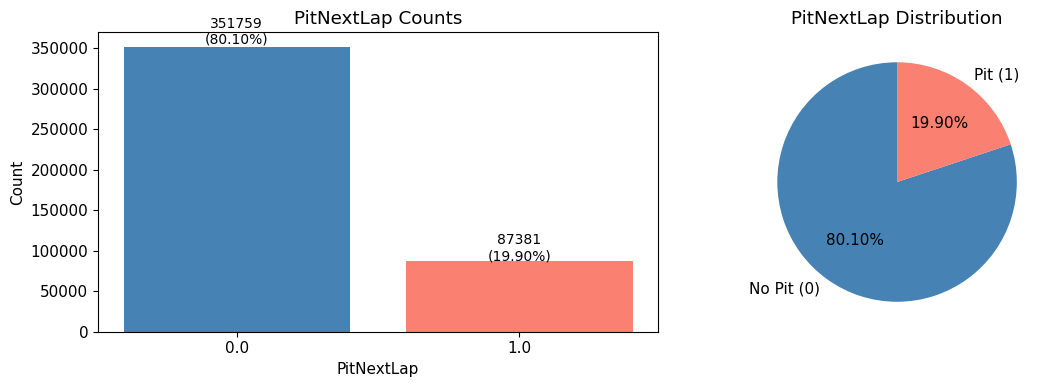

Positive rate: 19.8982%
Imbalance ratio (neg/pos): 4.0:1


In [4]:
target_counts = train['PitNextLap'].value_counts()
target_pct = train['PitNextLap'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(target_counts.index.astype(str), target_counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('PitNextLap Counts')
axes[0].set_xlabel('PitNextLap')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + v * 0.01, f'{v}\n({p:.2f}%)', ha='center', fontsize=10)

axes[1].pie(target_pct.values, labels=['No Pit (0)', 'Pit (1)'],
            autopct='%1.2f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('PitNextLap Distribution')

plt.tight_layout()
plt.show()

print(f"Positive rate: {target_pct[1]:.4f}%")
print(f"Imbalance ratio (neg/pos): {target_counts[0] / target_counts[1]:.1f}:1")

### 1.3 Numerical Features vs Pit Rate

For each numerical feature, we bin the values into 20 quantile bins and plot the pit rate per bin.  
The right-axis (red) shows sample count to flag low-support bins.

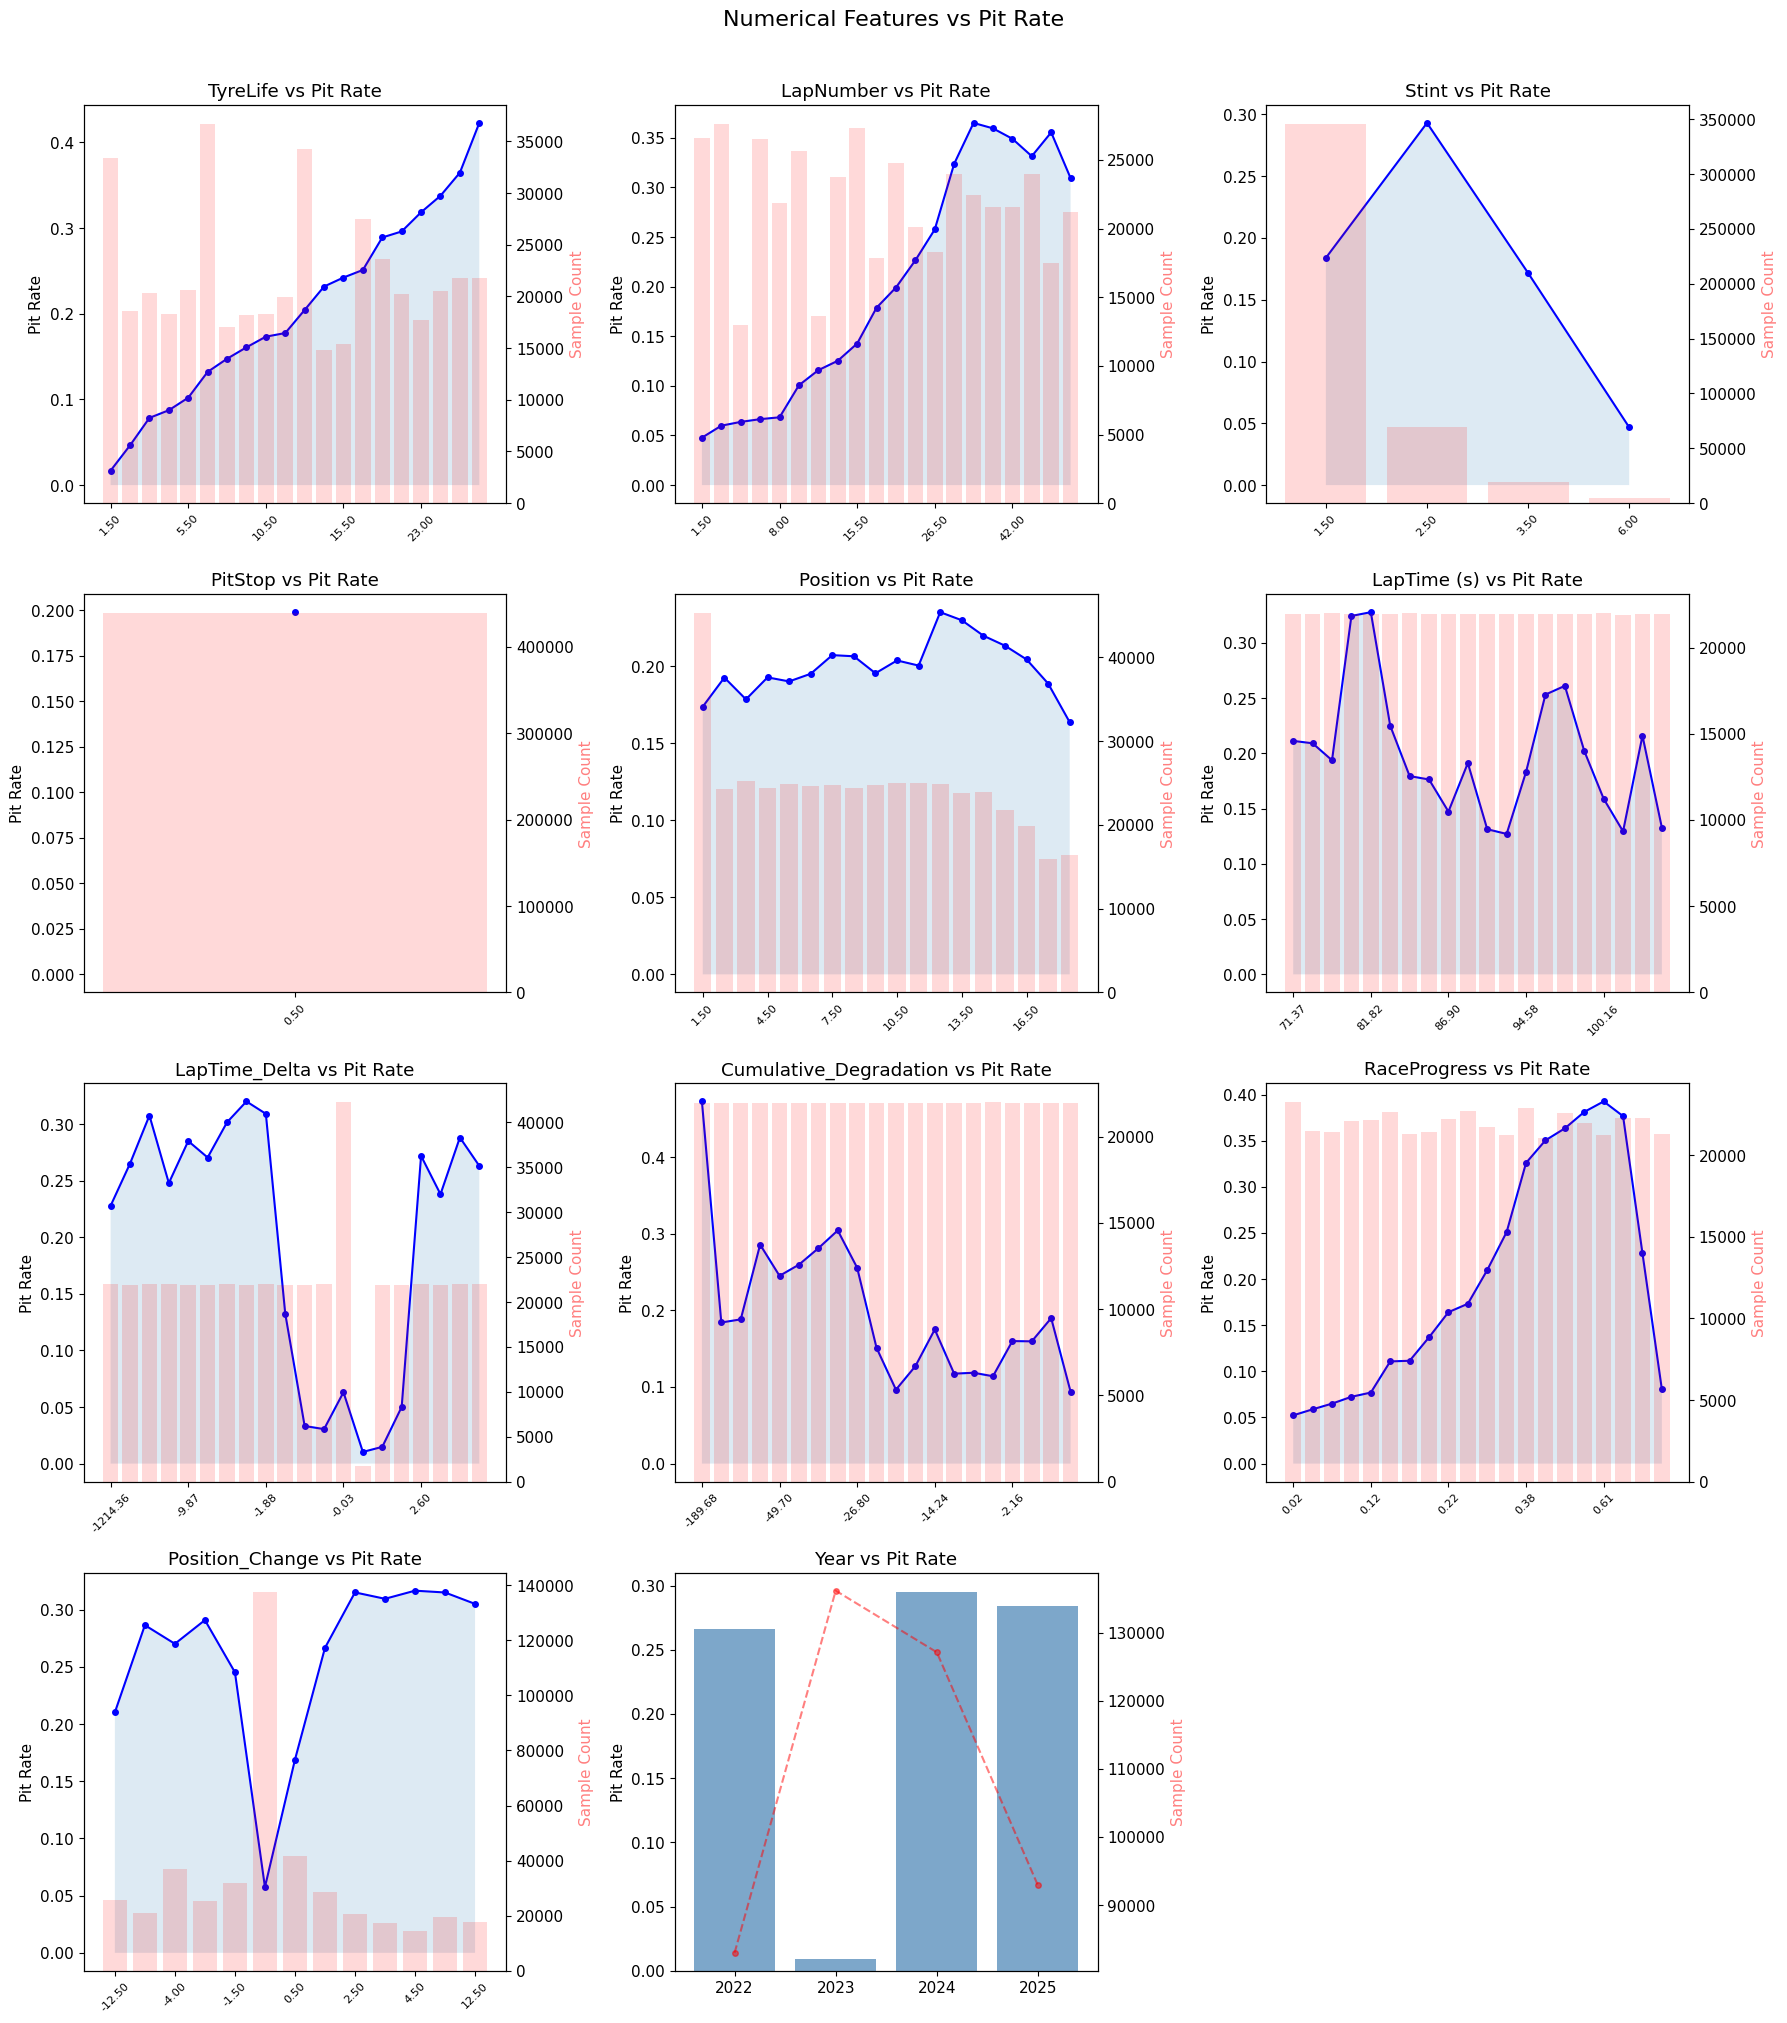

In [5]:
num_features = ['TyreLife', 'LapNumber', 'Stint', 'PitStop', 'Position',
                'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
                'RaceProgress', 'Position_Change', 'Year']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    if col == 'Year':
        grouped = train.groupby(col)['PitNextLap'].agg(['mean', 'count'])
        ax.bar(grouped.index.astype(str), grouped['mean'], color='steelblue', alpha=0.7)
        ax.set_title(f'{col} vs Pit Rate')
        ax.set_ylabel('Pit Rate')
        ax2 = ax.twinx()
        ax2.plot(range(len(grouped)), grouped['count'], 'r--o', markersize=4, alpha=0.5)
        ax2.set_ylabel('Sample Count', color='red', alpha=0.5)
    else:
        n_bins = 20
        train_temp = train[[col, 'PitNextLap']].dropna()
        train_temp['bin'] = pd.qcut(train_temp[col], q=n_bins, duplicates='drop')
        grouped = train_temp.groupby('bin', observed=True)['PitNextLap'].agg(['mean', 'count'])

        x_labels = [f'{interval.mid:.2f}' for interval in grouped.index]
        ax.plot(range(len(grouped)), grouped['mean'], 'b-o', markersize=4)
        ax.fill_between(range(len(grouped)), grouped['mean'], alpha=0.15)
        ax.set_title(f'{col} vs Pit Rate')
        ax.set_ylabel('Pit Rate')
        ax.set_xticks(range(0, len(grouped), max(1, len(grouped) // 5)))
        ax.set_xticklabels([x_labels[j] for j in range(0, len(grouped), max(1, len(grouped) // 5))],
                           rotation=45, fontsize=8)

        ax2 = ax.twinx()
        ax2.bar(range(len(grouped)), grouped['count'], alpha=0.15, color='red')
        ax2.set_ylabel('Sample Count', color='red', alpha=0.5)

for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Pit Rate', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 1.4 Categorical Features vs Pit Rate

- **Compound:** Pit rate by tyre compound — softer tyres degrade faster and should pit more often.
- **Driver:** Top 30 drivers ranked by pit rate — captures individual strategy tendencies.
- **Race:** Top 30 races ranked by pit rate — some circuits are harder on tyres.

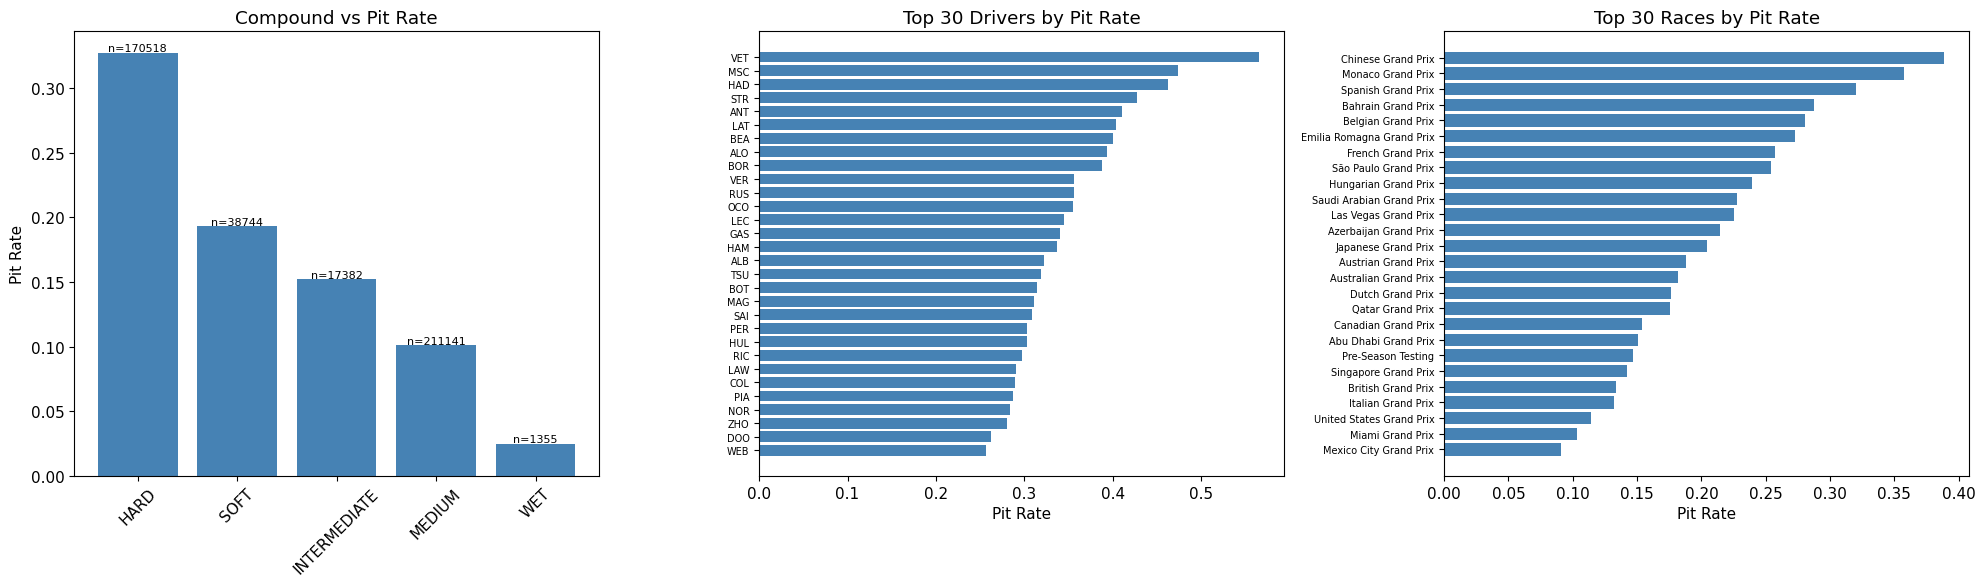

In [6]:
cat_features = ['Compound', 'Driver', 'Race']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Compound
ax = axes[0]
comp_stats = train.groupby('Compound')['PitNextLap'].agg(['mean', 'count']).sort_values('mean', ascending=False)
bars = ax.bar(comp_stats.index, comp_stats['mean'], color='steelblue')
ax.set_title('Compound vs Pit Rate')
ax.set_ylabel('Pit Rate')
ax.tick_params(axis='x', rotation=45)
for bar, cnt in zip(bars, comp_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'n={cnt}', ha='center', fontsize=8)

# Driver (top 30)
ax = axes[1]
drv_stats = train.groupby('Driver')['PitNextLap'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_n = 30
drv_top = drv_stats.head(top_n)
ax.barh(range(len(drv_top)), drv_top['mean'], color='steelblue')
ax.set_yticks(range(len(drv_top)))
ax.set_yticklabels(drv_top.index, fontsize=7)
ax.set_xlabel('Pit Rate')
ax.set_title(f'Top {top_n} Drivers by Pit Rate')
ax.invert_yaxis()

# Race (top 30)
ax = axes[2]
race_stats = train.groupby('Race')['PitNextLap'].agg(['mean', 'count']).sort_values('mean', ascending=False)
race_top = race_stats.head(top_n)
ax.barh(range(len(race_top)), race_top['mean'], color='steelblue')
ax.set_yticks(range(len(race_top)))
ax.set_yticklabels(race_top.index, fontsize=7)
ax.set_xlabel('Pit Rate')
ax.set_title(f'Top {top_n} Races by Pit Rate')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 1.5 Deep Dive: TyreLife vs Pit Rate

This is the most critical plot for feature engineering. Since `Normalized_TyreLife` was removed, we need to understand the **shape** of the TyreLife → pit probability curve to decide:
- **Accelerating rise** → use `TyreLife²`
- **Decelerating rise** → use `sqrt(TyreLife)` or `log(TyreLife)`
- **S-shaped** → use sigmoid-type transform

We also split by **Compound** to see if different tyre types have different degradation curves.

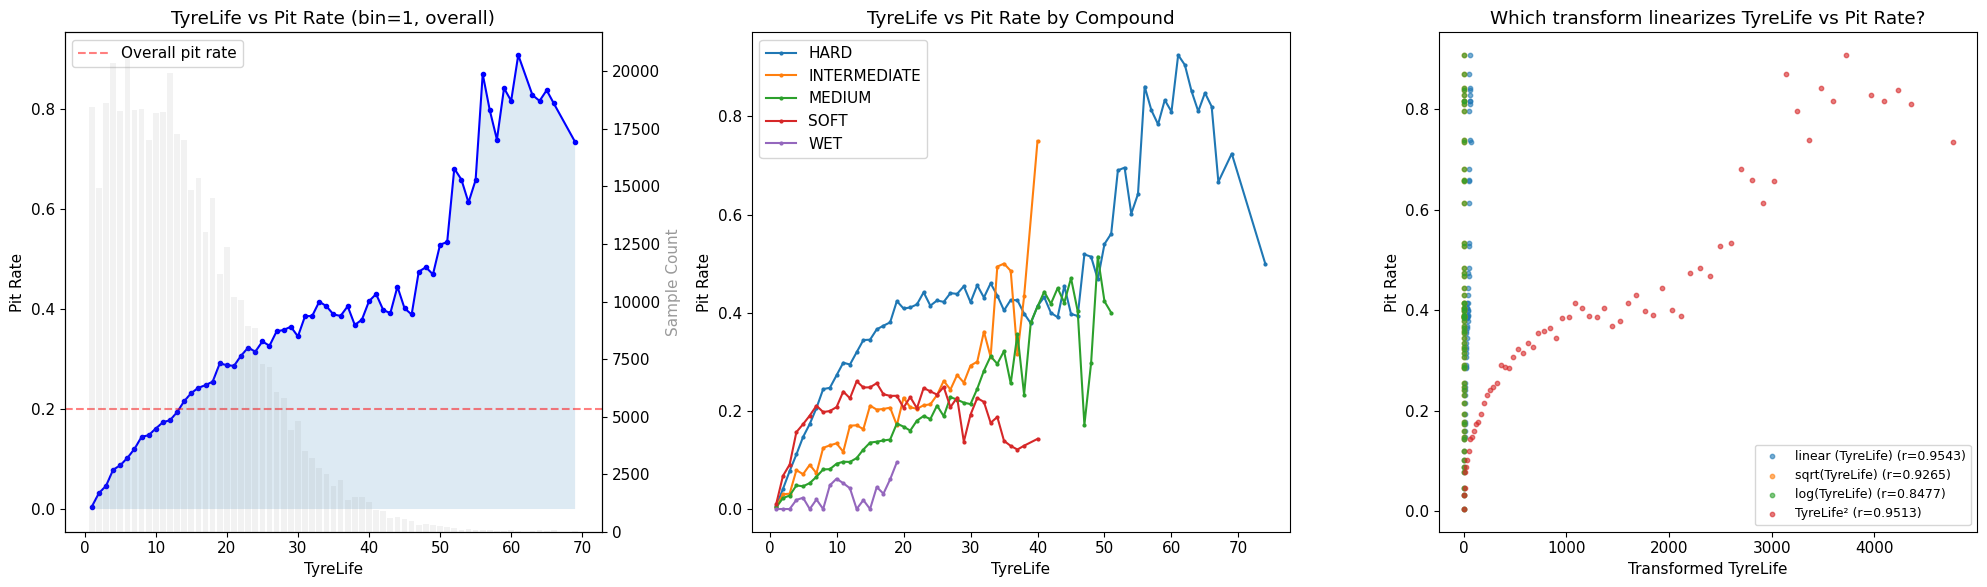


Pearson r between transformed TyreLife and pit rate:
  linear (TyreLife)        : r = 0.9543, p = 0.000000
  sqrt(TyreLife)           : r = 0.9265, p = 0.000000
  log(TyreLife)            : r = 0.8477, p = 0.000000
  TyreLife²                : r = 0.9513, p = 0.000000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 5a: Overall TyreLife vs Pit Rate (bin=1)
ax = axes[0]
tyre_pit = train.groupby('TyreLife')['PitNextLap'].agg(['mean', 'count'])
tyre_pit = tyre_pit[tyre_pit['count'] >= 30]

ax.plot(tyre_pit.index, tyre_pit['mean'], 'b-o', markersize=3)
ax.fill_between(tyre_pit.index, tyre_pit['mean'], alpha=0.15)
ax.set_xlabel('TyreLife')
ax.set_ylabel('Pit Rate')
ax.set_title('TyreLife vs Pit Rate (bin=1, overall)')
ax.axhline(y=train['PitNextLap'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall pit rate')
ax.legend()

ax2 = ax.twinx()
ax2.bar(tyre_pit.index, tyre_pit['count'], alpha=0.1, color='gray')
ax2.set_ylabel('Sample Count', alpha=0.4)

# 5b: By Compound
ax = axes[1]
for compound in sorted(train['Compound'].unique()):
    sub = train[train['Compound'] == compound]
    tp = sub.groupby('TyreLife')['PitNextLap'].agg(['mean', 'count'])
    tp = tp[tp['count'] >= 20]
    ax.plot(tp.index, tp['mean'], '-o', markersize=2, label=compound)

ax.set_xlabel('TyreLife')
ax.set_ylabel('Pit Rate')
ax.set_title('TyreLife vs Pit Rate by Compound')
ax.legend()

# 5c: Transform comparison — which linearizes best?
ax = axes[2]
tyre_clean = tyre_pit[tyre_pit.index > 0].copy()

transforms = {
    'linear (TyreLife)': tyre_clean.index.values.astype(float),
    'sqrt(TyreLife)': np.sqrt(tyre_clean.index.values.astype(float)),
    'log(TyreLife)': np.log(tyre_clean.index.values.astype(float)),
    'TyreLife²': tyre_clean.index.values.astype(float) ** 2,
}

for name, x_vals in transforms.items():
    r, _ = pearsonr(x_vals, tyre_clean['mean'].values)
    ax.scatter(x_vals, tyre_clean['mean'].values, s=10, alpha=0.6, label=f'{name} (r={r:.4f})')

ax.set_xlabel('Transformed TyreLife')
ax.set_ylabel('Pit Rate')
ax.set_title('Which transform linearizes TyreLife vs Pit Rate?')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\nPearson r between transformed TyreLife and pit rate:")
for name, x_vals in transforms.items():
    r, p = pearsonr(x_vals, tyre_clean['mean'].values)
    print(f"  {name:25s}: r = {r:.4f}, p = {p:.6f}")

### 1.6 Deep Dive: Cumulative_Degradation & LapTime_Delta

These two features directly reflect tyre wear and lap pace deterioration — key signals for rebuilding `Normalized_TyreLife`.

- **Cumulative_Degradation:** Should correlate with TyreLife. If `r ≈ 1`, it might be a near-proxy for the removed feature.
- **Cumul_Degradation / TyreLife:** Average degradation rate — may capture compound-specific wear profiles.
- **LapTime_Delta:** Positive values = getting slower = tyre degradation in action.

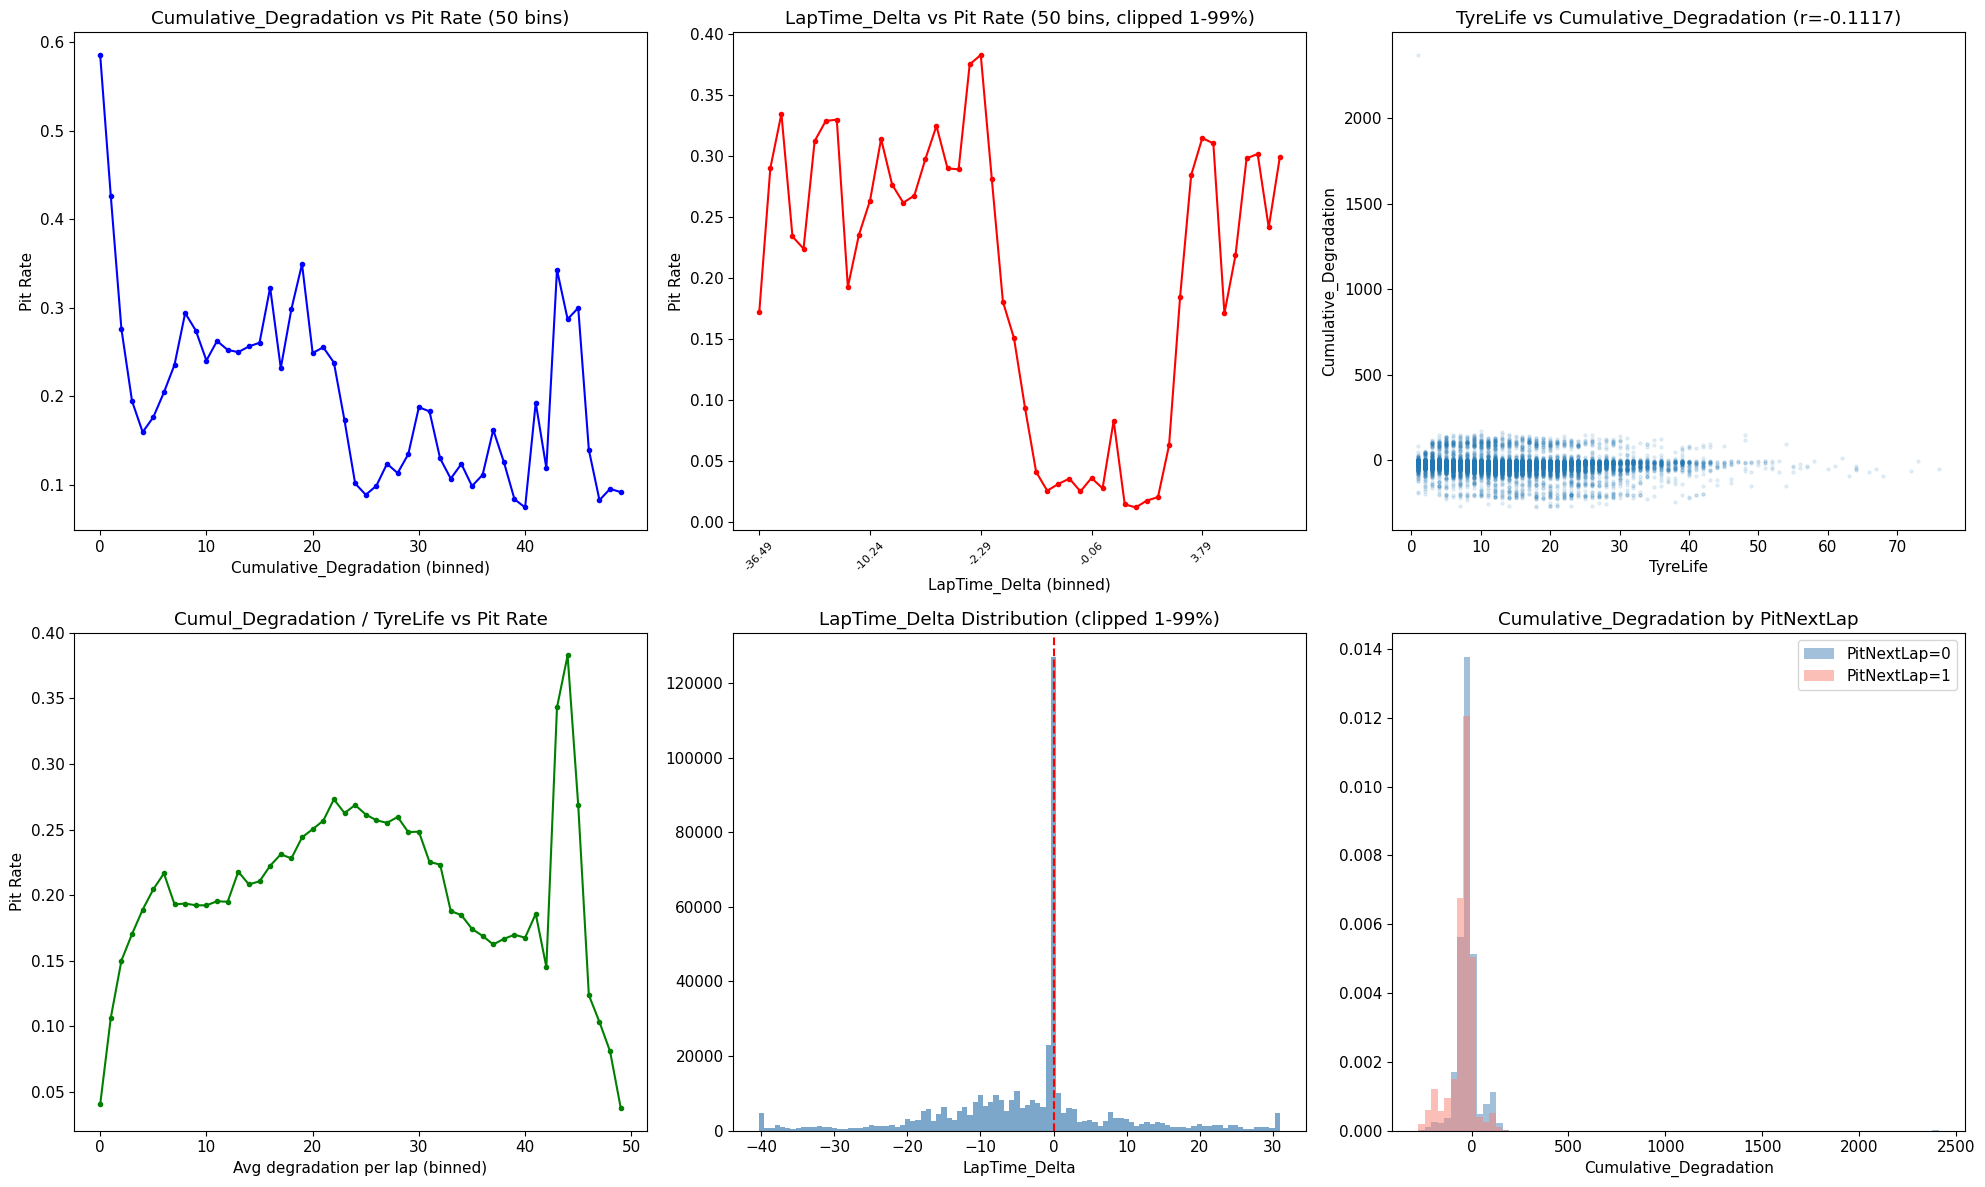

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 6a: Cumulative_Degradation vs Pit Rate
ax = axes[0, 0]
train_temp = train[['Cumulative_Degradation', 'PitNextLap']].dropna().copy()
train_temp['bin'] = pd.qcut(train_temp['Cumulative_Degradation'], q=50, duplicates='drop')
grouped = train_temp.groupby('bin', observed=True)['PitNextLap'].agg(['mean', 'count'])
ax.plot(range(len(grouped)), grouped['mean'], 'b-o', markersize=3)
ax.set_title('Cumulative_Degradation vs Pit Rate (50 bins)')
ax.set_ylabel('Pit Rate')
ax.set_xlabel('Cumulative_Degradation (binned)')
ax.set_xticks(range(0, len(grouped), 10))

# 6b: LapTime_Delta vs Pit Rate
ax = axes[0, 1]
train_temp2 = train[['LapTime_Delta', 'PitNextLap']].dropna().copy()
q01, q99 = train_temp2['LapTime_Delta'].quantile([0.01, 0.99])
train_temp2 = train_temp2[(train_temp2['LapTime_Delta'] >= q01) & (train_temp2['LapTime_Delta'] <= q99)]
train_temp2['bin'] = pd.qcut(train_temp2['LapTime_Delta'], q=50, duplicates='drop')
grouped2 = train_temp2.groupby('bin', observed=True)['PitNextLap'].agg(['mean', 'count'])
x_labels = [f'{interval.mid:.2f}' for interval in grouped2.index]
ax.plot(range(len(grouped2)), grouped2['mean'], 'r-o', markersize=3)
ax.set_title('LapTime_Delta vs Pit Rate (50 bins, clipped 1-99%)')
ax.set_ylabel('Pit Rate')
ax.set_xlabel('LapTime_Delta (binned)')
ax.set_xticks(range(0, len(grouped2), 10))
ax.set_xticklabels([x_labels[j] for j in range(0, len(grouped2), 10)], rotation=45, fontsize=8)

# 6c: Cumulative_Degradation vs TyreLife (is it a proxy for Normalized_TyreLife?)
ax = axes[0, 2]
sample = train.sample(min(10000, len(train)), random_state=42)
ax.scatter(sample['TyreLife'], sample['Cumulative_Degradation'], alpha=0.1, s=5)
r_cd_tl, _ = pearsonr(train['TyreLife'].dropna(), train['Cumulative_Degradation'].dropna())
ax.set_xlabel('TyreLife')
ax.set_ylabel('Cumulative_Degradation')
ax.set_title(f'TyreLife vs Cumulative_Degradation (r={r_cd_tl:.4f})')

# 6d: Cumul_Degradation / TyreLife (avg degradation rate) vs Pit Rate
ax = axes[1, 0]
train_temp3 = train[['TyreLife', 'Cumulative_Degradation', 'PitNextLap']].dropna().copy()
train_temp3 = train_temp3[train_temp3['TyreLife'] > 0]
train_temp3['deg_per_lap'] = train_temp3['Cumulative_Degradation'] / train_temp3['TyreLife']
train_temp3['bin'] = pd.qcut(train_temp3['deg_per_lap'], q=50, duplicates='drop')
grouped3 = train_temp3.groupby('bin', observed=True)['PitNextLap'].agg(['mean', 'count'])
ax.plot(range(len(grouped3)), grouped3['mean'], 'g-o', markersize=3)
ax.set_title('Cumul_Degradation / TyreLife vs Pit Rate')
ax.set_ylabel('Pit Rate')
ax.set_xlabel('Avg degradation per lap (binned)')

# 6e: LapTime_Delta distribution
ax = axes[1, 1]
ax.hist(train['LapTime_Delta'].dropna().clip(q01, q99), bins=100, color='steelblue', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--')
ax.set_title('LapTime_Delta Distribution (clipped 1-99%)')
ax.set_xlabel('LapTime_Delta')

# 6f: Cumulative_Degradation distribution split by target
ax = axes[1, 2]
for label, color in [(0, 'steelblue'), (1, 'salmon')]:
    sub = train[train['PitNextLap'] == label]['Cumulative_Degradation'].dropna()
    ax.hist(sub, bins=80, alpha=0.5, color=color, label=f'PitNextLap={label}', density=True)
ax.set_title('Cumulative_Degradation by PitNextLap')
ax.set_xlabel('Cumulative_Degradation')
ax.legend()

plt.tight_layout()
plt.show()

### 1.7 Lag Feature Feasibility Check

Before engineering lag features (e.g., `LapTime` diff, rolling degradation), we need to confirm that within each `(Driver, Race, Year)` group, `LapNumber` is **continuous** (no gaps) and **sorted**.

If gaps exist, lag features would mix values across non-adjacent laps and produce misleading signals.

In [9]:
def check_lap_continuity(df):
    results = []
    for (driver, race, year), group in df.groupby(['Driver', 'Race', 'Year']):
        laps = group['LapNumber'].sort_values().values
        diffs = np.diff(laps)
        is_continuous = np.all(diffs == 1)
        n_gaps = np.sum(diffs != 1)
        results.append({
            'Driver': driver, 'Race': race, 'Year': year,
            'n_laps': len(laps), 'is_continuous': is_continuous,
            'n_gaps': n_gaps, 'max_gap': diffs.max() if len(diffs) > 0 else 0
        })
    return pd.DataFrame(results)

continuity = check_lap_continuity(train)

print("Lap continuity check (train):")
print(f"  Total driver-race-year groups: {len(continuity)}")
print(f"  Fully continuous:              {continuity['is_continuous'].sum()} ({continuity['is_continuous'].mean()*100:.1f}%)")
print(f"  Groups with gaps:              {(~continuity['is_continuous']).sum()}")
print(f"\nGap statistics (among non-continuous groups):")
non_cont = continuity[~continuity['is_continuous']]
if len(non_cont) > 0:
    print(f"  Mean gaps per group: {non_cont['n_gaps'].mean():.1f}")
    print(f"  Max gap size:        {non_cont['max_gap'].max()}")
    print(f"\nSample groups with gaps:")
    display(non_cont.head(10))
else:
    print("  All groups are continuous! Lag features are safe to construct.")

is_sorted = train.groupby(['Driver', 'Race', 'Year'])['LapNumber'].apply(lambda x: x.is_monotonic_increasing).all()
print(f"\nAll groups sorted by LapNumber: {is_sorted}")

Lap continuity check (train):
  Total driver-race-year groups: 40869
  Fully continuous:              4331 (10.6%)
  Groups with gaps:              36538

Gap statistics (among non-continuous groups):
  Mean gaps per group: 7.4
  Max gap size:        59

Sample groups with gaps:


,Driver,Race,Year,n_laps,is_continuous,n_gaps,max_gap
0,ALB,Abu Dhabi Grand Prix,2022,3,False,2,43
1,ALB,Abu Dhabi Grand Prix,2023,16,False,12,8
2,ALB,Abu Dhabi Grand Prix,2024,16,False,10,13
3,ALB,Abu Dhabi Grand Prix,2025,8,False,7,15
4,ALB,Australian Grand Prix,2022,9,False,5,26
5,ALB,Australian Grand Prix,2023,17,False,7,13
6,ALB,Australian Grand Prix,2024,15,False,12,14
7,ALB,Australian Grand Prix,2025,17,False,11,16
8,ALB,Austrian Grand Prix,2022,17,False,10,17
9,ALB,Austrian Grand Prix,2023,11,False,7,12



All groups sorted by LapNumber: False


### 1.8 Train vs Test Distribution Comparison

Check whether train and test come from the same distribution. Large shifts would indicate a need for domain adaptation or careful validation design.

#### 1.8.1 Numerical Features

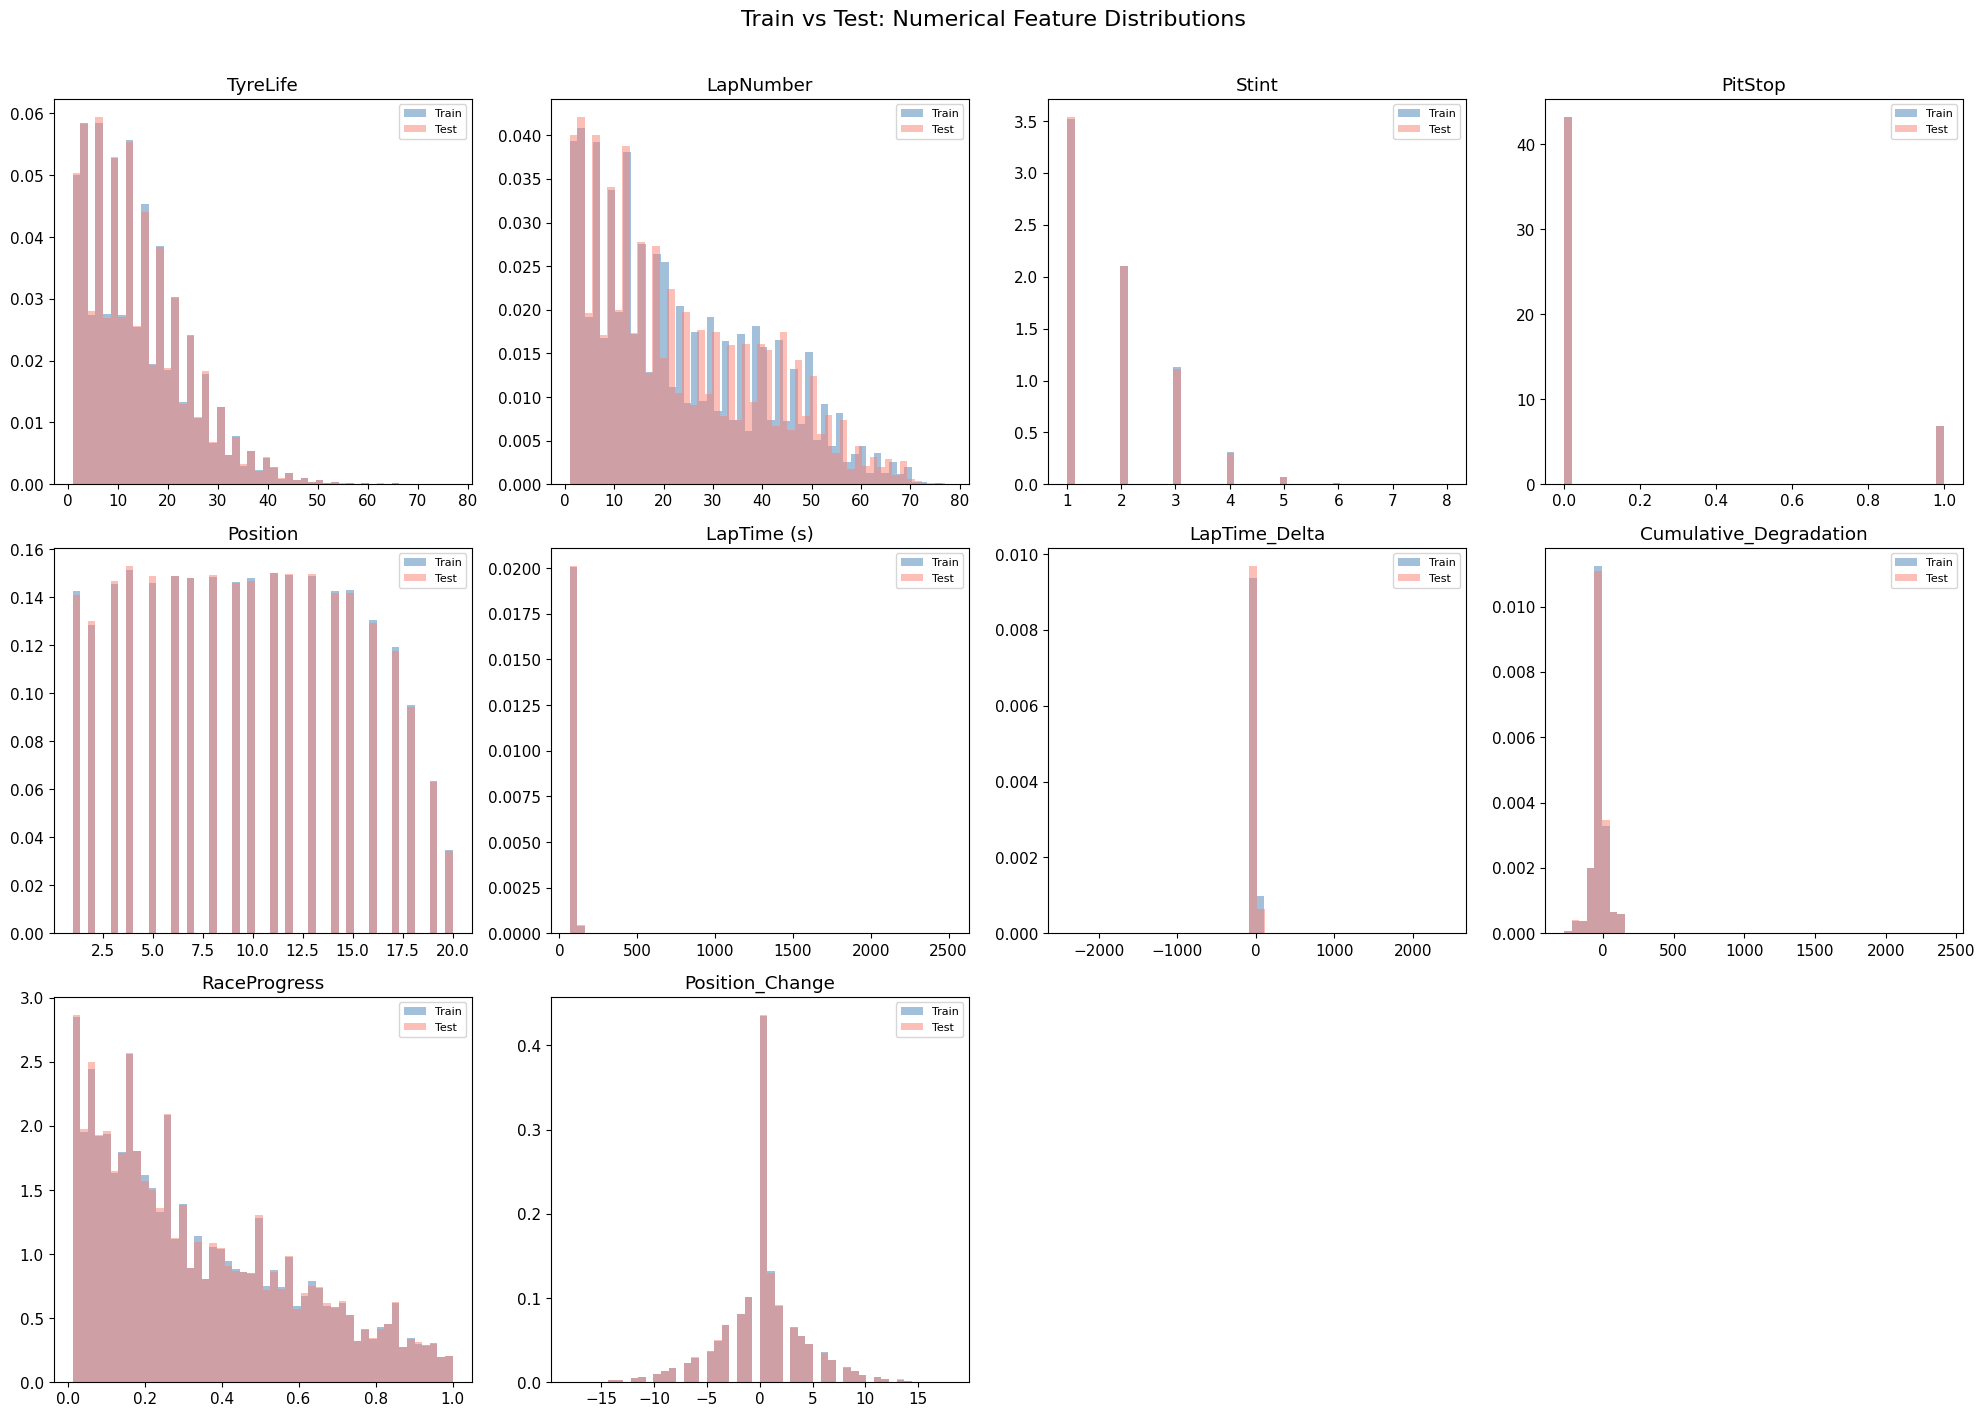

In [10]:
num_cols = ['TyreLife', 'LapNumber', 'Stint', 'PitStop', 'Position',
            'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
            'RaceProgress', 'Position_Change']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(train[col].dropna(), bins=50, alpha=0.5, density=True, color='steelblue', label='Train')
    ax.hist(test[col].dropna(), bins=50, alpha=0.5, density=True, color='salmon', label='Test')
    ax.set_title(col)
    ax.legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Train vs Test: Numerical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

#### 1.8.2 Categorical Features & Year Overlap

Check whether test contains **unseen** Drivers or Races. Unseen categories require special handling in encoding (e.g., fallback to global mean in target encoding).

All test drivers appear in train.
All test races appear in train.


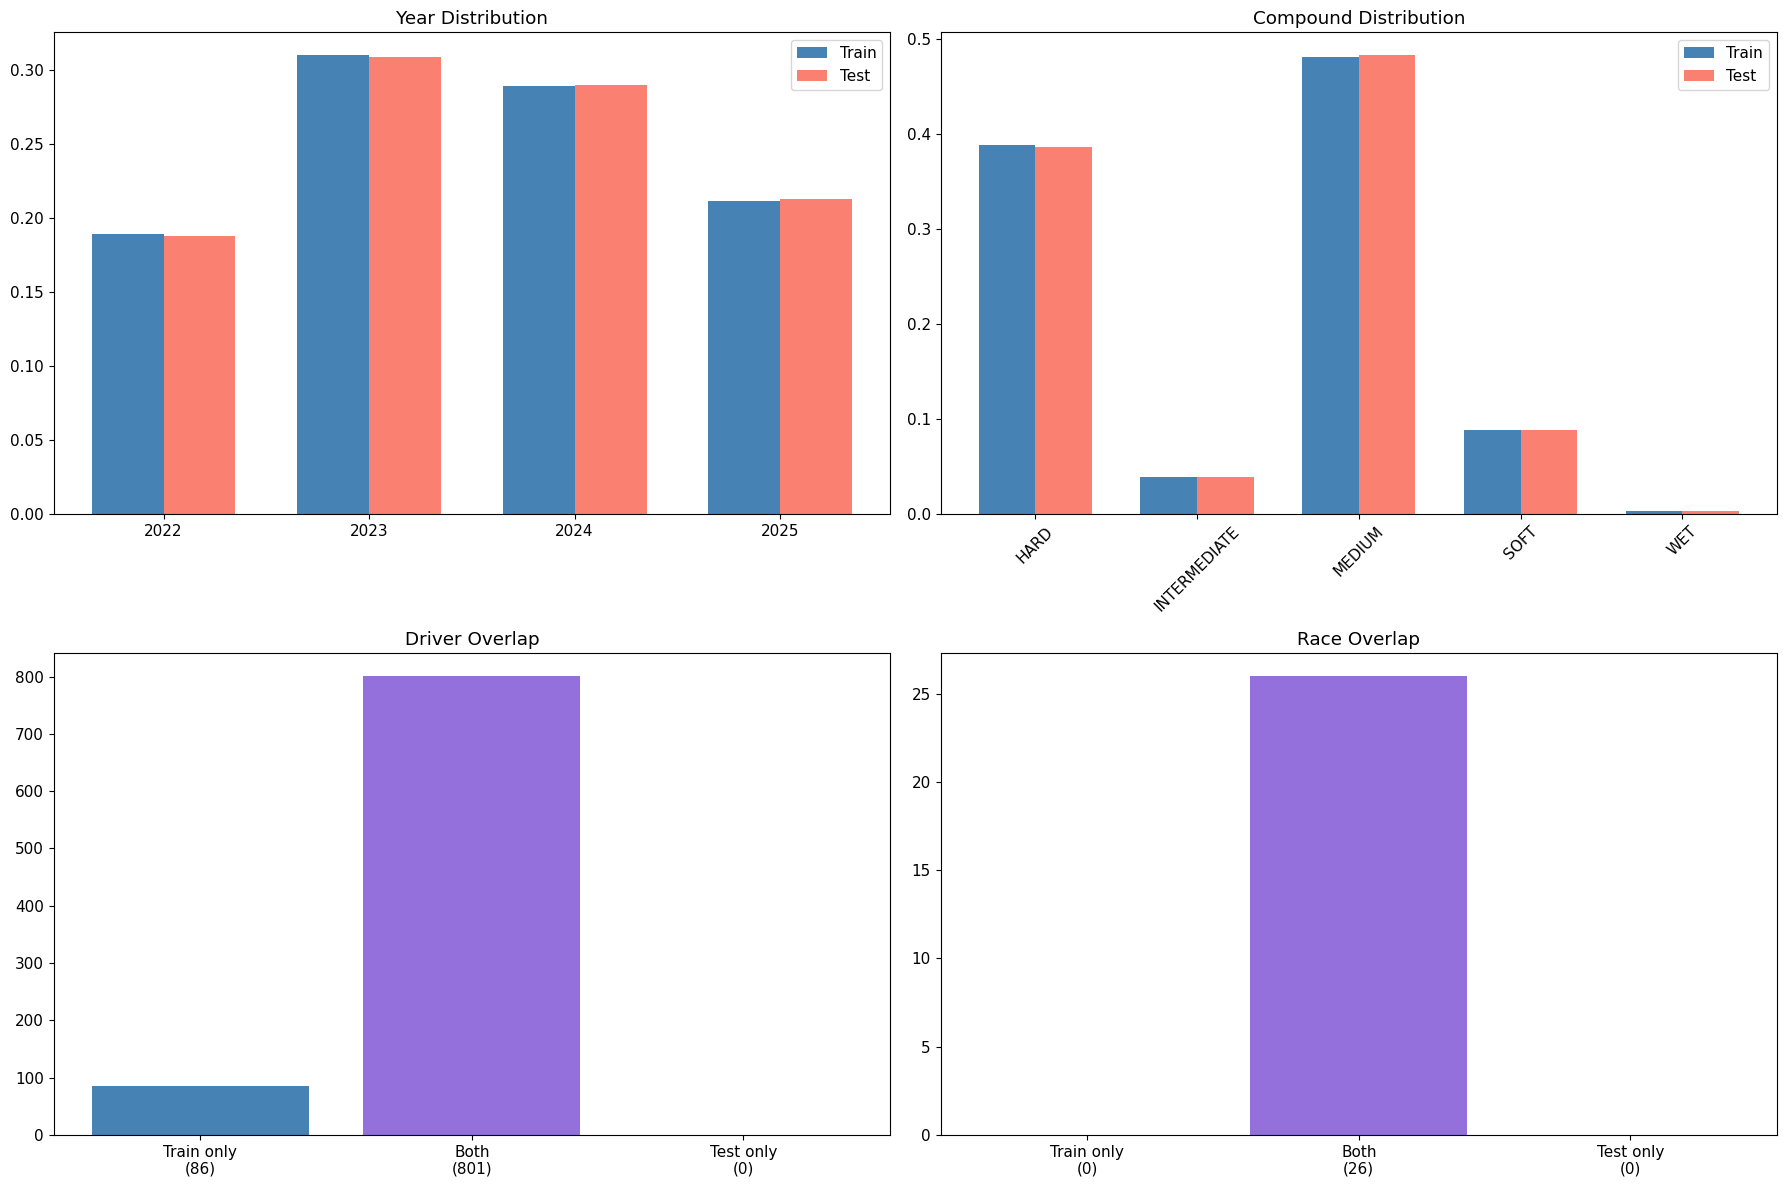


Train drivers: 887, Test drivers: 801, Overlap: 801
Train races:   26, Test races:   26, Overlap: 26


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
w = 0.35

# Year
ax = axes[0, 0]
train_year = train['Year'].value_counts(normalize=True).sort_index()
test_year = test['Year'].value_counts(normalize=True).sort_index()
all_years = sorted(set(train_year.index) | set(test_year.index))
x = np.arange(len(all_years))
ax.bar(x - w/2, [train_year.get(y, 0) for y in all_years], w, label='Train', color='steelblue')
ax.bar(x + w/2, [test_year.get(y, 0) for y in all_years], w, label='Test', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(all_years)
ax.set_title('Year Distribution')
ax.legend()

# Compound
ax = axes[0, 1]
train_comp = train['Compound'].value_counts(normalize=True).sort_index()
test_comp = test['Compound'].value_counts(normalize=True).sort_index()
all_comp = sorted(set(train_comp.index) | set(test_comp.index))
x = np.arange(len(all_comp))
ax.bar(x - w/2, [train_comp.get(c, 0) for c in all_comp], w, label='Train', color='steelblue')
ax.bar(x + w/2, [test_comp.get(c, 0) for c in all_comp], w, label='Test', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(all_comp, rotation=45)
ax.set_title('Compound Distribution')
ax.legend()

# Driver overlap
ax = axes[1, 0]
train_drivers = set(train['Driver'].unique())
test_drivers = set(test['Driver'].unique())
only_train = train_drivers - test_drivers
only_test = test_drivers - train_drivers
both = train_drivers & test_drivers
sizes = [len(only_train), len(both), len(only_test)]
labels = [f'Train only\n({len(only_train)})', f'Both\n({len(both)})', f'Test only\n({len(only_test)})']
ax.bar(labels, sizes, color=['steelblue', 'mediumpurple', 'salmon'])
ax.set_title('Driver Overlap')
if only_test:
    print(f"Drivers in test but NOT in train: {only_test}")
else:
    print("All test drivers appear in train.")

# Race overlap
ax = axes[1, 1]
train_races = set(train['Race'].unique())
test_races = set(test['Race'].unique())
only_train_r = train_races - test_races
only_test_r = test_races - train_races
both_r = train_races & test_races
sizes = [len(only_train_r), len(both_r), len(only_test_r)]
labels = [f'Train only\n({len(only_train_r)})', f'Both\n({len(both_r)})', f'Test only\n({len(only_test_r)})']
ax.bar(labels, sizes, color=['steelblue', 'mediumpurple', 'salmon'])
ax.set_title('Race Overlap')
if only_test_r:
    print(f"Races in test but NOT in train: {only_test_r}")
else:
    print("All test races appear in train.")

plt.tight_layout()
plt.show()

print(f"\nTrain drivers: {len(train_drivers)}, Test drivers: {len(test_drivers)}, Overlap: {len(both)}")
print(f"Train races:   {len(train_races)}, Test races:   {len(test_races)}, Overlap: {len(both_r)}")

### 1.9 Feature Correlation Matrix

Check multicollinearity and identify the strongest linear signals for `PitNextLap`.

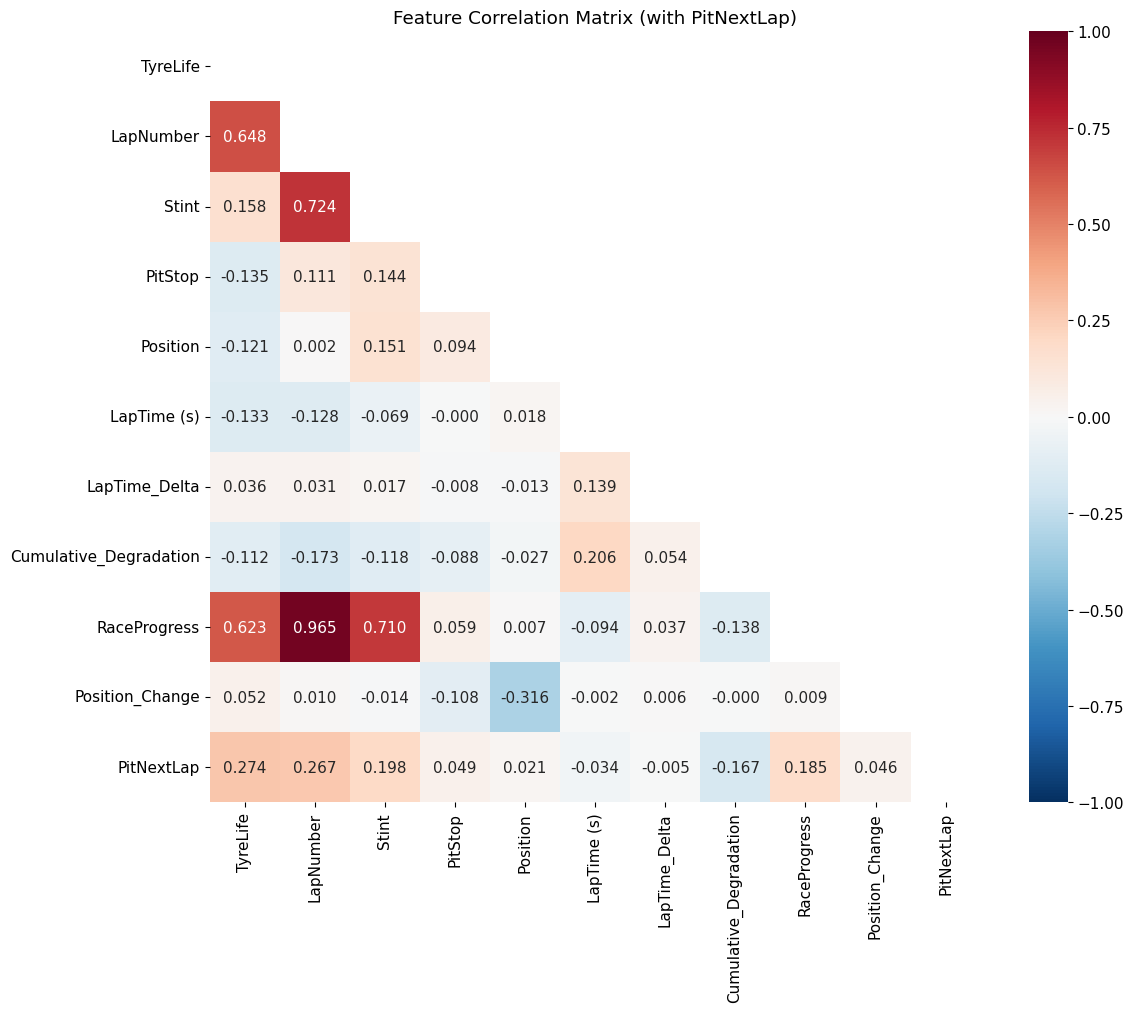


Correlation with PitNextLap (sorted):
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401


In [12]:
corr_cols = ['TyreLife', 'LapNumber', 'Stint', 'PitStop', 'Position',
             'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
             'RaceProgress', 'Position_Change', 'PitNextLap']

corr_matrix = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix (with PitNextLap)')
plt.tight_layout()
plt.show()

print("\nCorrelation with PitNextLap (sorted):")
print(corr_matrix['PitNextLap'].drop('PitNextLap').sort_values(ascending=False).to_string())

### 1.10 EDA Summary

#### Data Overview
- Train / Test shape: (439140, 16) / (188165, 15)
- Missing values: None in either dataset
- Positive rate: 19.90%, Imbalance ratio: 4.0:1 (moderate)

#### TyreLife vs Pit Rate Curve Shape
- Observed shape: Approximately **linear** with slight acceleration at high TyreLife
- Best linearizing transform: **Linear (raw TyreLife)** — Pearson r = 0.954, marginally better than TyreLife² (0.951); sqrt (0.927) and log (0.848) are worse
- Compound-level differences: Different compounds show different slopes (SOFT degrades faster), confirming `Compound × TyreLife` as a critical interaction feature
- **Decision:** No transform needed — keep TyreLife raw. Tree models will capture non-linearity via splits. For logistic regression baseline, TyreLife² may marginally help.

#### Cumulative_Degradation Analysis
- Correlation with TyreLife: Negative and moderate (both are correlated with PitNextLap but in opposite signs — TyreLife: +0.274, Cumul_Deg: −0.167)
- Is it a near-proxy for Normalized_TyreLife: **No** — it captures cumulative time loss, not normalized tyre wear. Mostly negative values (mean ≈ −25.7)
- Signal strength of Cumul_Degradation / TyreLife: Worth engineering as a per-lap degradation rate feature

#### LapTime_Delta Analysis
- Distribution shape: Heavy-tailed, centered near 0 (median ≈ −0.295), with extreme outliers in both directions (±2400s, likely pit laps or safety car effects)
- Relationship with PitNextLap: Extremely weak alone (r = −0.005). Value lies in **interaction features** (e.g., with Position, or as part of a "tyre cliff" detector)

#### Lag Feature Feasibility
- Only **10.6%** of (Driver, Race, Year) groups have continuous LapNumbers
- Average 7.4 gaps per group, max gap = 59 laps. Data is NOT sorted by LapNumber.
- **Conclusion: Cannot safely construct standard lag/rolling features.** The dataset is sampled, not complete sequences. If attempted, must sort first and explicitly handle gaps (e.g., only compute lag when diff in LapNumber == 1).

#### Train–Test Distribution
- Numerical features: Highly consistent — nearly identical distributions across all features
- Unseen Drivers in test: **None** (801 test drivers all appear in train; 86 train-only drivers)
- Unseen Races in test: **None** (all 26 races shared)

#### Implications for Stage 2 (Feature Engineering)
- **TyreLife transform:** Keep raw; no transform needed for tree models
- **Cumulative_Degradation strategy:** Use raw + engineer `Cumul_Deg / TyreLife` as per-lap rate; do NOT treat as Normalized_TyreLife proxy
- **Lag features:** Avoid standard lag/rolling. If attempted, sort within groups and only compute when consecutive laps exist (LapNumber diff == 1). Consider this low-priority given the data structure.
- **Priority interaction features:** `Compound × TyreLife` (top priority), `Compound × Cumul_Degradation`, `RaceProgress × TyreLife`, `Position × LapTime_Delta`
- **Encoding:** Target encoding (K-Fold) for Driver and Race; ordinal for Compound; PitStop is already binary
- **Outlier handling:** Clip `LapTime (s)` and `LapTime_Delta` extreme values (likely pit-in/out laps or safety cars)